# EDA INSURANCE


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

## Funciones EDA

In [3]:
def calculos_boxplot(columna, coef=1.5):
    """
    Calcula el Rango Intercuartílico (IQR) y los límites para valores considerados
    válidos (no extremos).
    -------------------------------
    Parametros de entrada:
    - columna: columna de un dataframe o Serie de Pandas
    - coef: valor del coeficiente para el cálculo de los límites válidos, por defecto 1.5
        Se puede ampliar si se quiere "relajar" la exigencia para dichos valores

    -------------------------------
    SALIDA:
    Devuelve una tupla (limite_inferior, limite_superior)
    y muestra por pantalla información

    """

    Q1, Q3 = columna.quantile([0.25,0.75])

    IQR = Q3 - Q1

    lim_inferior = Q1 - coef*IQR
    lim_superior = Q3 + coef*IQR

    print('Cuartiles: ', Q1, '\t', Q3)
    print('IQR: ',IQR)
    print('Limite inferior: ', lim_inferior)
    print('Limite superior: ', lim_superior)

    return lim_inferior, lim_superior


In [4]:
def categoricas_unicos(dataframe, var_cat, vc_out=True):
    """
    Muestra valores unicos y conteo de las variables categóricas.
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_cat: lista de variables categóricas (cadena)
    - vc_out: booleano para mostrar o no (True/False) el resultado de "value_counts()"
        Por defecto lo muestra

    -------------------------------
    SALIDA:
    No devuelve valor. Saca por pantalla la información

    """

    for discreta in var_cat:

        print(f'Variable {discreta.upper()}:')
        print('Valores unicos: ')
        print(dataframe[discreta].unique(), end='\n'*2)

        if vc_out:
            print(dataframe[discreta].value_counts(), end='\n'*2)





In [5]:
def graf_histo_box_numericas(dataframe, var_num):
    """
    Realiza graficas histograma y boxplot de variables numéricas de un dataframe
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_num: lista de variables numéricas (cadena)

    -------------------------------
    SALIDA:
    No devuelve valor. Dibuja las gráficas por pantalla

    """

    TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
                   'tab:gray','tab:olive', 'tab:cyan')

    fig, axes = plt.subplots(len(var_num), 2, \
                             figsize=(20, 5 * len(var_num)), \
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    ax = axes.ravel()

    # graficas distribucion y boxplot de cada atributo
    for idx, atributo in enumerate(var_num):

        # distribucion (histograma)
        sns.histplot(dataframe[atributo], ax=ax[2 * idx], \
                     color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                     alpha=0.15, kde=True)

        # titulo, etiquetas histograma
        ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
        ax[2 * idx].set_xlabel(f'Valores {atributo}')
        ax[2 * idx].set_ylabel("Frequencia")

        # boxplot
        sns.boxplot(x=atributo, data=dataframe, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

        # titulo, etiquetas boxplot
        ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
        ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')



# Lectura archivo

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:

ruta = '/content/drive/MyDrive/ESPECIALISTA IA/insurance.csv'

df_insurance = pd.read_csv(ruta)

df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Información general

In [8]:
df_insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Caso particular: discretización (pasar de una variable numérica a categórica) por intervalos

Usualmente en medicina el BMI en vez de utilizarlo como nº se definen una serie de intervalos. Vanos a discretizar por intervalos la columna "bmi":

In [9]:
df_insurance.drop_duplicates(inplace=True)

In [10]:
limites = [0, 18.5, 25, 30, 100]
etiquetas = ["BAJO", "NORMAL", "SOBREPESO", "OBESIDAD"]

df_insurance["bmi_cat"] = pd.cut(df_insurance["bmi"], bins=limites, labels=etiquetas, right=False)

df_insurance.bmi_cat.value_counts()

,count
bmi_cat,
OBESIDAD,706
SOBREPESO,386
NORMAL,225
BAJO,20


In [11]:
df_insurance.sample(10)[["bmi", "bmi_cat"]]

,bmi,bmi_cat
204,22.300,NORMAL
983,30.590,OBESIDAD
986,30.115,OBESIDAD
234,24.510,NORMAL
1219,30.210,OBESIDAD
393,31.350,OBESIDAD
32,28.600,SOBREPESO
646,26.220,SOBREPESO
12,34.400,OBESIDAD
867,43.700,OBESIDAD


In [12]:
df_insurance.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   object  
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   object  
 5   region    1337 non-null   object  
 6   charges   1337 non-null   float64 
 7   bmi_cat   1337 non-null   category
dtypes: category(1), float64(2), int64(2), object(3)
memory usage: 85.1+ KB


- No tiene sentido para el estudio mantener las 2 variables (original y discretizada). Vamos a eliminar la original:

In [13]:
df_insurance.drop(columns="bmi", inplace=True)

In [14]:
df_insurance.describe()

,age,children,charges
count,1337.000000,1337.000000,1337.000000
mean,39.222139,1.095737,13279.121487
std,14.044333,1.205571,12110.359656
min,18.000000,0.000000,1121.873900
25%,27.000000,0.000000,4746.344000
50%,39.000000,1.000000,9386.161300
75%,51.000000,2.000000,16657.717450
max,64.000000,5.000000,63770.428010


In [15]:
df_insurance.describe(include=["object", "category"])

,sex,smoker,region,bmi_cat
count,1337,1337,1337,1337
unique,2,2,4,4
top,male,no,southeast,OBESIDAD
freq,675,1063,364,706


# UNIDIMENSIONALES

In [16]:
var_num = df_insurance.select_dtypes(include="number").columns.to_list()
var_num

['age', 'children', 'charges']

In [17]:
var_cat = df_insurance.select_dtypes(include=["object", "category"]).columns.to_list()
var_cat

['sex', 'smoker', 'region', 'bmi_cat']

## Numéricas

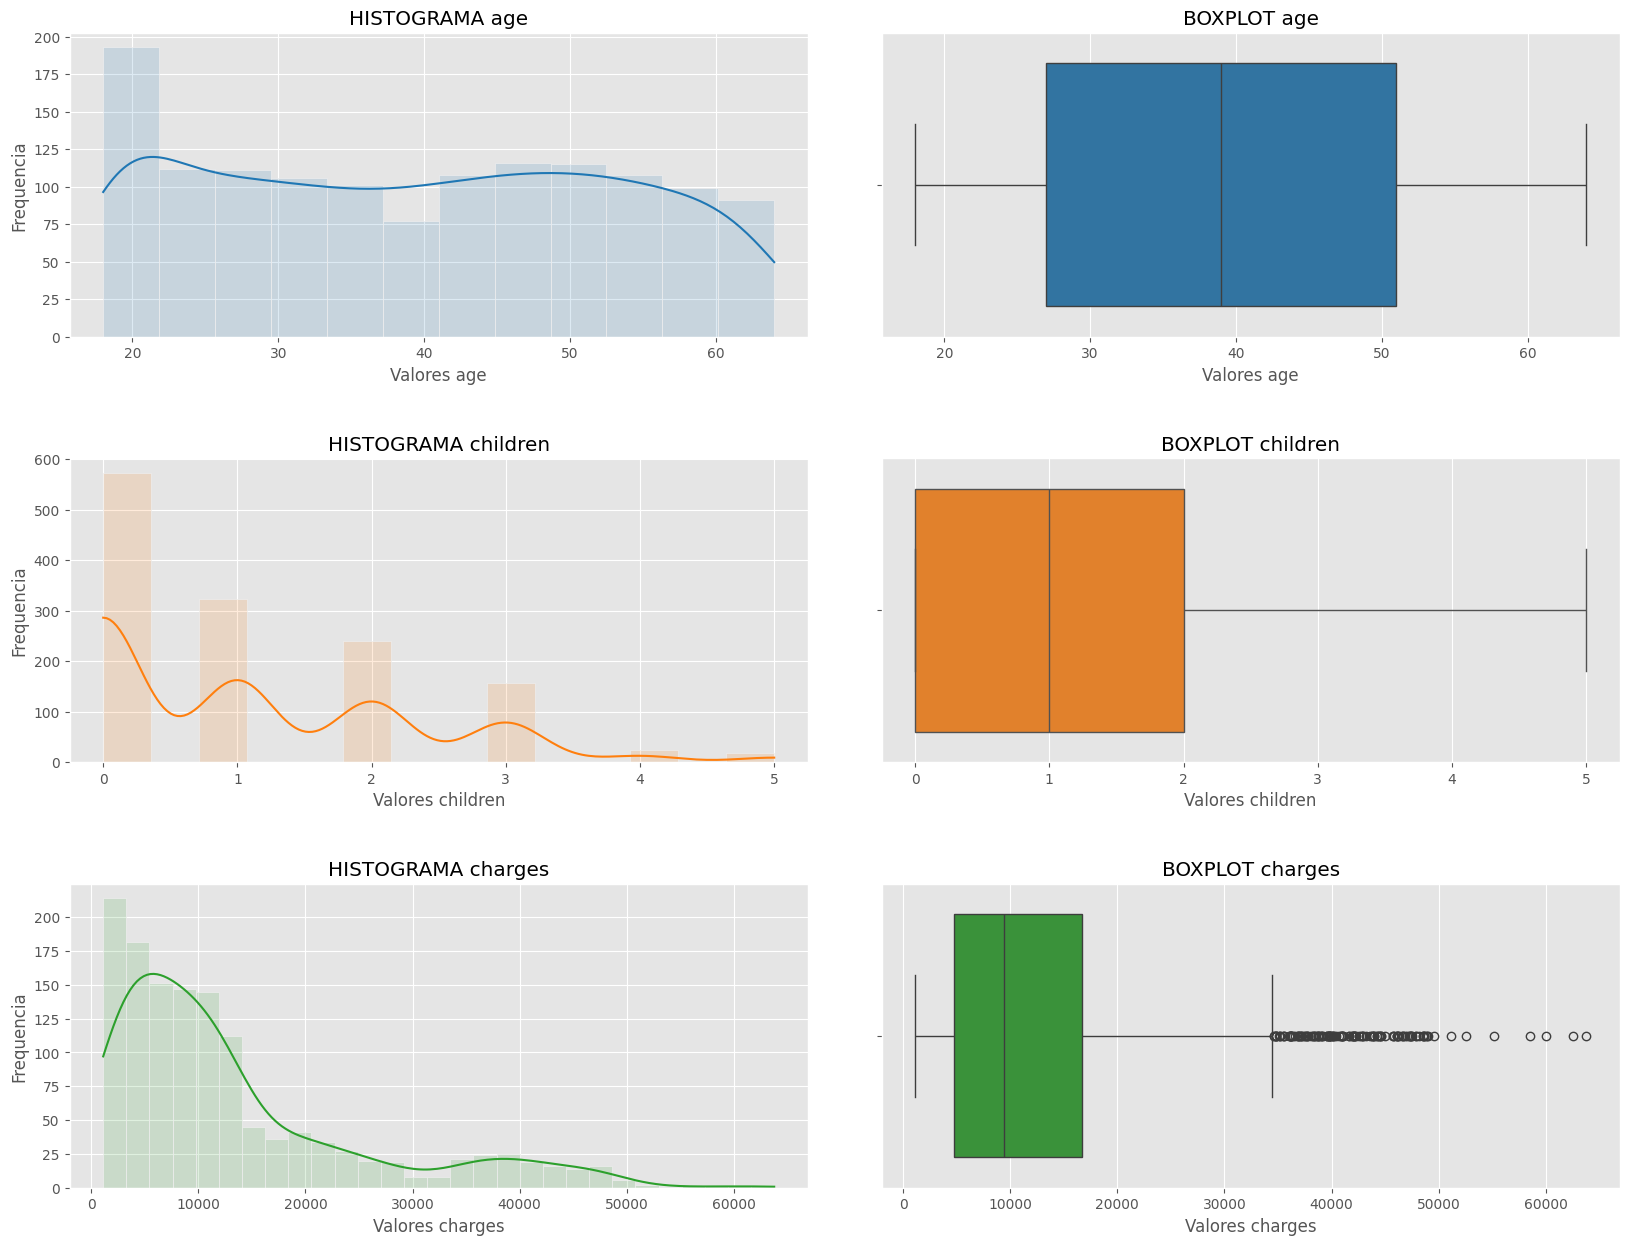

In [18]:
graf_histo_box_numericas(df_insurance, var_num)

In [19]:
var_cat

['sex', 'smoker', 'region', 'bmi_cat']

<Axes: xlabel='region', ylabel='count'>

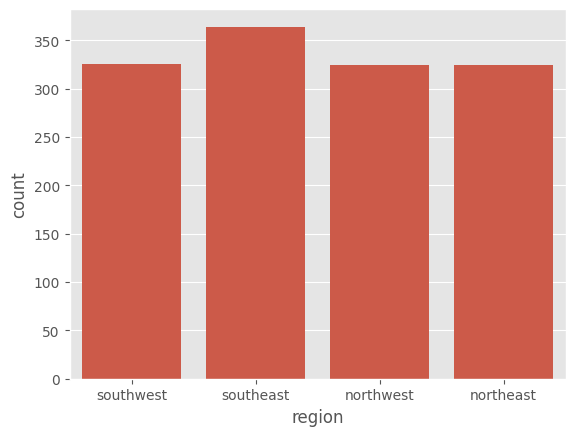

In [20]:
sns.countplot(data=df_insurance, x="region")

<Axes: xlabel='sex', ylabel='count'>

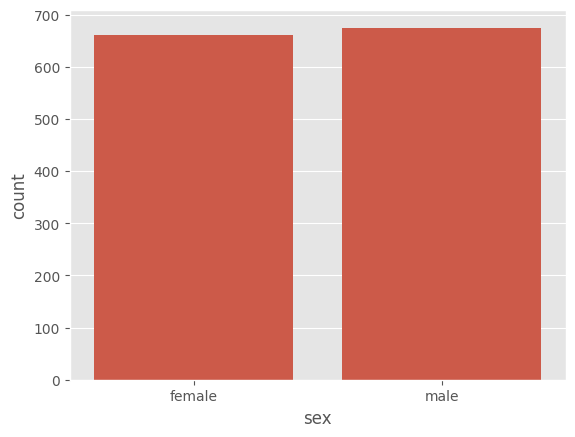

In [21]:
sns.countplot(data=df_insurance, x="sex")

In [22]:
df_insurance.sex.value_counts()

,count
sex,
male,675
female,662


<Axes: xlabel='smoker', ylabel='count'>

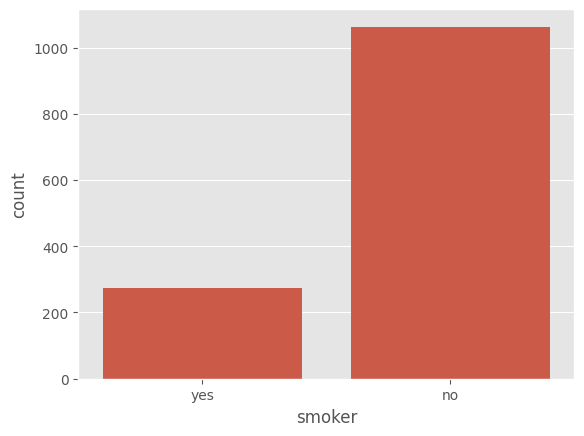

In [23]:
sns.countplot(data=df_insurance, x="smoker")

<Axes: xlabel='bmi_cat', ylabel='count'>

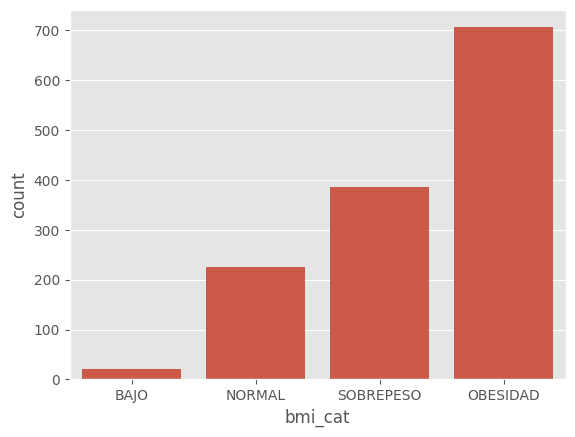

In [24]:
sns.countplot(data=df_insurance, x="bmi_cat")

# ANALISIS BI Y MULTIDIMENSIONAL

## NUMERICO-NUMERICO.

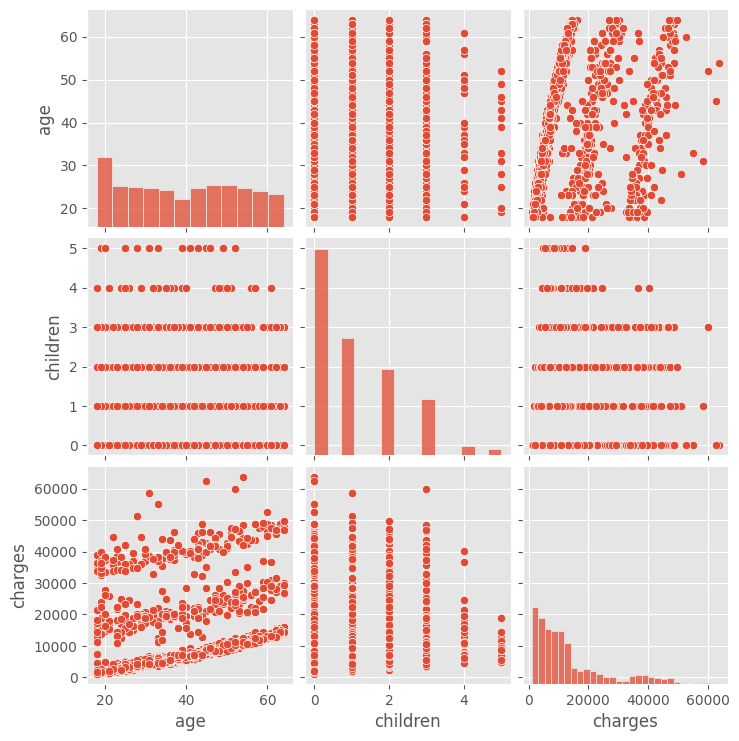

In [25]:
sns.pairplot(df_insurance)

In [26]:
mat_corr = df_insurance.corr(numeric_only=True)
mat_corr

,age,children,charges
age,1.000000,0.041536,0.298308
children,0.041536,1.000000,0.067389
charges,0.298308,0.067389,1.000000


Text(0.5, 1.0, 'Correlacion entre atributos')

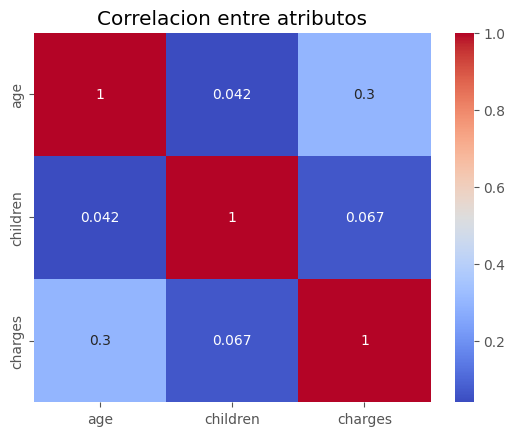

In [27]:
sns.heatmap(mat_corr, annot=True, cbar=True, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title("Correlacion entre atributos")

## NUMERICO-CATEGORICO

In [28]:
var_cat

['sex', 'smoker', 'region', 'bmi_cat']

In [29]:
var_num

['age', 'children', 'charges']

<Axes: xlabel='charges', ylabel='smoker'>

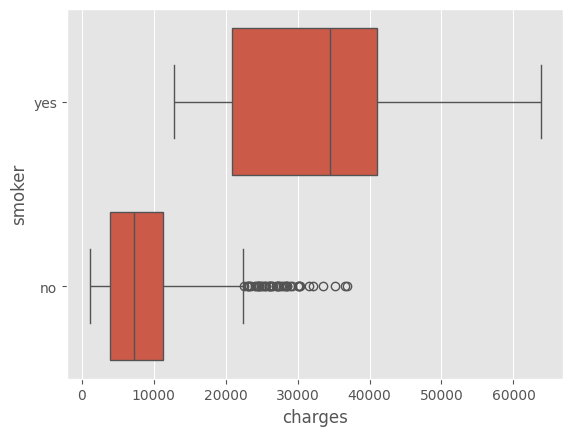

In [30]:
sns.boxplot(data=df_insurance, x="charges", y="smoker")

<Axes: xlabel='charges', ylabel='bmi_cat'>

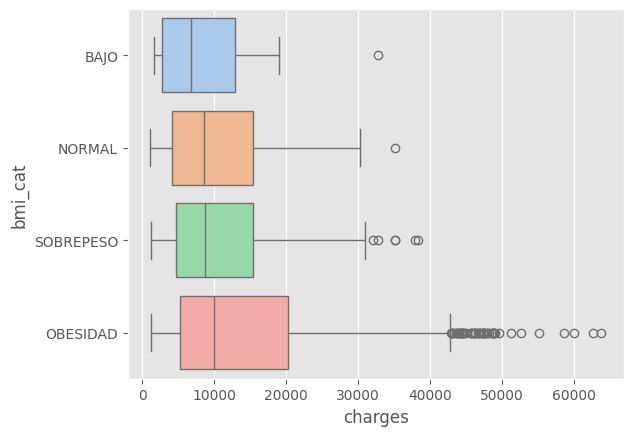

In [31]:
sns.boxplot(data=df_insurance, x="charges", y="bmi_cat", palette="pastel")

<Axes: xlabel='charges', ylabel='region'>

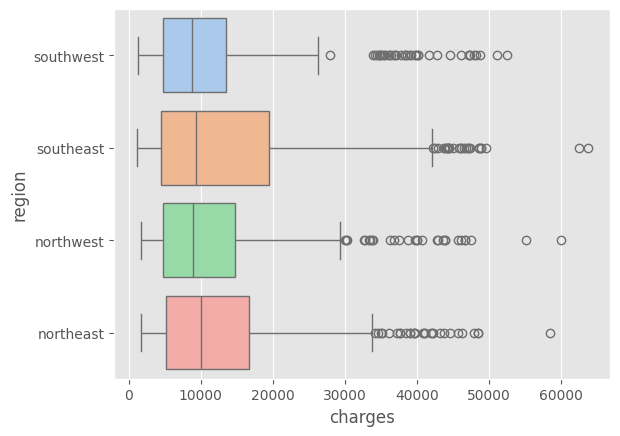

In [32]:
sns.boxplot(data=df_insurance, x="charges", y="region", palette="pastel")

## CATEGÓRICAS-CATEGORICAS

In [33]:
var_cat

['sex', 'smoker', 'region', 'bmi_cat']

<Axes: xlabel='smoker', ylabel='count'>

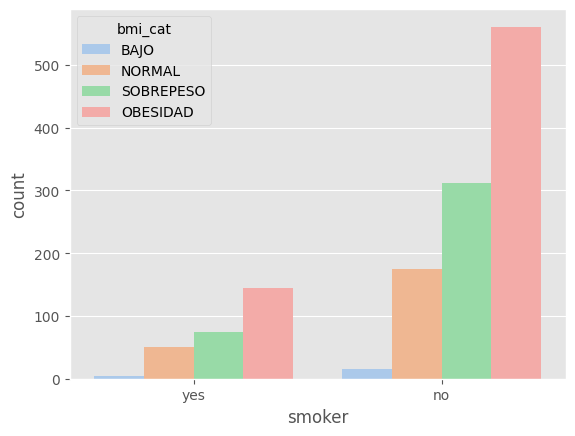

In [34]:
sns.countplot(data=df_insurance, x="smoker", hue="bmi_cat", palette="pastel")

<Axes: xlabel='bmi_cat', ylabel='Count'>

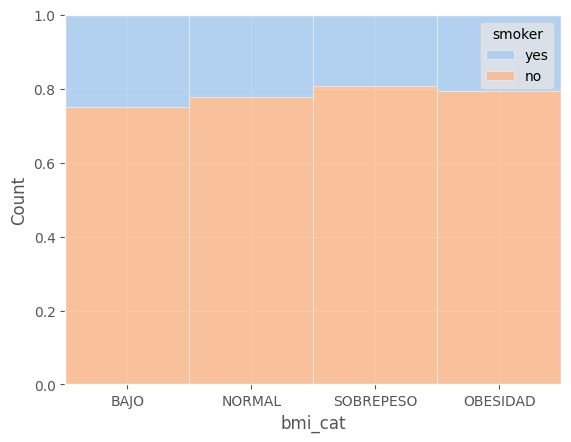

In [35]:
sns.histplot(data=df_insurance, x="bmi_cat", hue="smoker", multiple="fill", palette="pastel")

## OUTLIERS

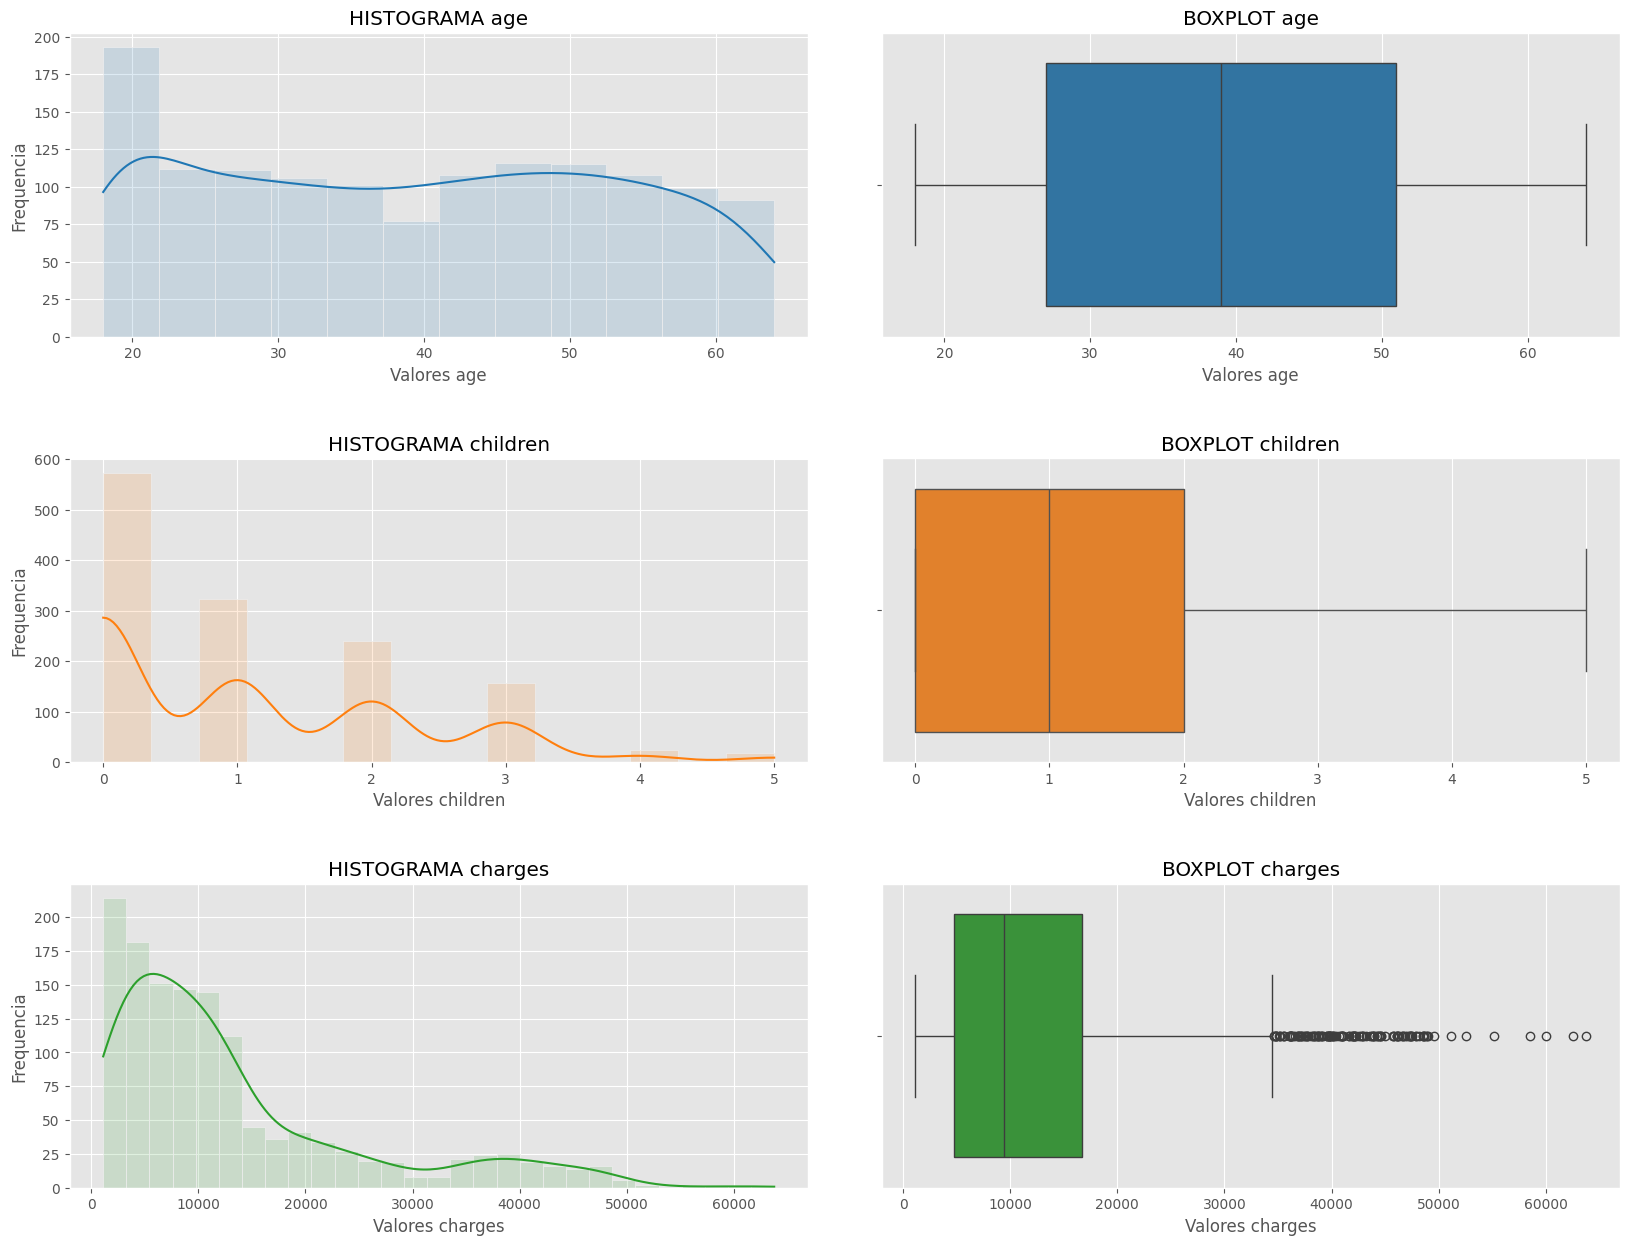

In [36]:
graf_histo_box_numericas(df_insurance, var_num)

In [37]:
len(df_insurance[df_insurance.charges>50000])

7

In [38]:
df_insurance[df_insurance.charges>50000].describe()

,age,children,charges
count,7.000000,7.000000,7.000000
mean,43.285714,0.714286,57696.652167
std,12.671678,1.112697,4863.802290
min,28.000000,0.000000,51194.559140
25%,32.000000,0.000000,53863.115740
50%,45.000000,0.000000,58571.074480
75%,53.000000,1.000000,61307.136030
max,60.000000,3.000000,63770.428010


In [39]:
df_insurance[df_insurance.charges>50000].describe(include=["object", "category"])

,sex,smoker,region,bmi_cat
count,7,7,7,7
unique,2,1,4,1
top,male,yes,southwest,OBESIDAD
freq,4,7,2,7


MUY POCOS, AUNQUE TODOS CON OBESIDAD Y FUMADORES. Decisión difícil, aunque hay que señalar que 7 filas son insignificantes

**Para el grupo de outliers más próximos**

In [40]:
lim_inf, lim_sup = calculos_boxplot(df_insurance.charges)

Cuartiles:  4746.344 	 16657.71745
IQR:  11911.37345
Limite inferior:  -13120.716174999998
Limite superior:  34524.777625


In [41]:
len(df_insurance[(df_insurance.charges>lim_sup) & (df_insurance.charges<50000)])

132

**Dado el tamaño del dataset, no podemos despreciar ni podemos eliminar estas filas**